In [232]:
import os
import math
import time
import random
import json
from typing import Tuple, Dict, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from PIL import Image
from scipy import ndimage

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Датасеты / трансформации
import torchvision
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms import functional as F
from torchvision.transforms import InterpolationMode
import torch.nn.functional as Fn

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [261]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Детеминизм (может замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 19
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = True   # переключите на True для частичного датасета и более быстрого обучения
DATA_DIR = "./data"

Device: cpu


### Часть A (S10): датасет для классификации изображений

In [3]:
STL10_MEAN = (0.4479, 0.4412, 0.4075)
STL10_STD  = (0.2600, 0.2564, 0.2708)

def get_stl10_transforms():
    # Базовый transform для CNN
    basic_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD)
    ])
    
    # Transform с аугментациями
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(96, padding=8),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD)
    ])
    
    # Preprocessing для pretrained ResNet
    resnet_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD)
    ])
    
    return basic_transform, train_transform, resnet_transform

basic_transform, train_transform, resnet_transform = get_stl10_transforms()

In [6]:
stl10_train = torchvision.datasets.STL10(
    root=DATA_DIR, 
    split='train', 
    transform=basic_transform, 
    download=True
)

stl10_test = torchvision.datasets.STL10(
    root=DATA_DIR, 
    split='test', 
    transform=basic_transform, 
    download=True
)

# Разделение train на train/val (80/20)
train_size = int(0.8 * len(stl10_train))
val_size = len(stl10_train) - train_size
stl10_train_split, stl10_val = random_split(
    stl10_train, [train_size, val_size], 
    generator=torch.Generator()
)

In [18]:
batch_size = 64
train_loader_A = DataLoader(stl10_train_split, batch_size=batch_size, shuffle=True)
val_loader_A = DataLoader(stl10_val, batch_size=batch_size, shuffle=False)
test_loader_A = DataLoader(stl10_test, batch_size=batch_size, shuffle=False)
class_names_A = stl10_train.classes

print(f"Train: {len(train_loader_A.dataset)}, Val: {len(val_loader_A.dataset)}, Test: {len(test_loader_A.dataset)}")

Train: 4000, Val: 1000, Test: 8000


In [19]:
# Sanity-check для STL10
dataiter = iter(train_loader_A)
images, labels = next(dataiter)
    
print(f"Batch size: {images.shape}, Labels: {labels.shape}")
print(f"x.shape: {images.shape}, y.shape: {labels.shape}")
print(f"Classes: {class_names_A}")

Batch size: torch.Size([64, 3, 96, 96]), Labels: torch.Size([64])
x.shape: torch.Size([64, 3, 96, 96]), y.shape: torch.Size([64])
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


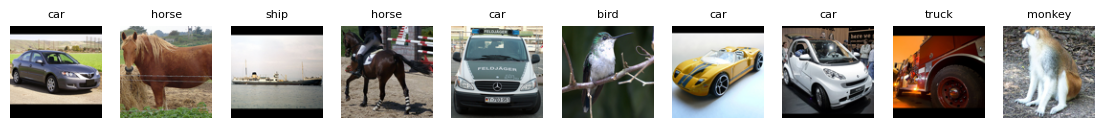

In [21]:
def denorm_stl(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_stl(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names_A[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader_A, n=10)

### Часть B (S11): датасет для детекции или сегментации

In [41]:
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = True
    n_show: int = 3
    person_only: bool = True  # мы считаем IoU только по классу "person"

cfg = RunConfig()
cfg

RunConfig(data_dir='./data', fast_mode=True, n_show=3, person_only=True)

In [208]:
OXFORD_URL = "http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
ANNOT_URL = "http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"

def ensure_oxford_pet(root: str) -> str:
    oxford_root = os.path.join(root, "oxford-iiit-pet")
    if os.path.isdir(oxford_root):
        # Проверяем наличие ключевых папок
        if os.path.exists(os.path.join(oxford_root, "images")) and \
           os.path.exists(os.path.join(oxford_root, "annotations")):
            return oxford_root
        else:
            print("Найдена папка, но отсутствуют images/annotations. Перезагружаем...")

    os.makedirs(root, exist_ok=True)
    try:
        import torchvision
        from torchvision.datasets.utils import download_and_extract_archive
        
        print("Downloading Oxford-IIIT Pet to:", root)
        
        # Скачиваем images
        download_and_extract_archive(OXFORD_URL, download_root=root, 
                                   filename="images.tar.gz", remove_finished=True)
        
        # Скачиваем annotations  
        download_and_extract_archive(ANNOT_URL, download_root=root,
                                   filename="annotations.tar.gz", remove_finished=True)
        
        if not os.path.isdir(oxford_root):
            # Создаем основную папку и перемещаем содержимое
            os.makedirs(oxford_root, exist_ok=True)
            import shutil
            for folder in ["images", "annotations"]:
                src = os.path.join(root, folder)
                dst = os.path.join(oxford_root, folder)
                if os.path.exists(src):
                    shutil.move(src, dst)
        
        if not os.path.isdir(os.path.join(oxford_root, "images")):
            raise FileNotFoundError("После распаковки не найдено oxford-iiit-pet/images/")
            
        print(f"Датасет готов: {oxford_root}")
        return oxford_root
        
    except Exception as e:
        print("Не удалось автоматически скачать датасет.")
        print("Ошибка:", repr(e))
        print("\nВариант вручную:")
        print("1) Скачайте:")
        print(f"   images: {OXFORD_URL}")
        print(f"   annotations: {ANNOT_URL}")
        print(f"2) Распакуйте в {oxford_root}/images и {oxford_root}/annotations")
        raise

# Использование
oxford_root = ensure_oxford_pet(cfg.data_dir)
oxford_root


'./data\\oxford-iiit-pet'

In [210]:
class OxfordPetSegDataset(torch.utils.data.Dataset):
    def __init__(self, root: str):
        self.root = root
        self.img_dir = os.path.join(root, "images")
        self.mask_dir = os.path.join(root, "annotations", "trimaps")
        
        if not os.path.exists(self.mask_dir):
            raise RuntimeError(f"Не найдена папка масок: {self.mask_dir}")

        self.imgs = sorted([f for f in os.listdir(self.img_dir) 
                           if f.lower().endswith((".jpg", ".jpeg"))])
        self.masks = [f.replace('.jpg', '.png').replace('.jpeg', '.png') 
                     for f in self.imgs]

        # Проверяем что все маски существуют
        missing_masks = [m for m in self.masks if not os.path.exists(os.path.join(self.mask_dir, m))]
        if len(self.imgs) == 0 or len(missing_masks) > 0:
            raise RuntimeError(f"Похоже, структура OxfordIIITPet повреждена. "
                             f"Отсутствует {len(missing_masks)} масок из {len(self.imgs)} изображений.")

    def __len__(self) -> int:
        return len(self.imgs)

    def __getitem__(self, idx: int):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # Grayscale

        # trimap mask -> бинарная маска "питомец" (2=pet, 1=border, 3=background)
        mask_np = np.array(mask)
        gt = (mask_np == 2).astype(np.uint8)  # [H,W], 0/1 только питомец

        return img, gt  # img = PIL, gt = numpy

# Использование
dataset_B = OxfordPetSegDataset(oxford_root)
print(f"Размер датасета: {len(dataset)}")
print(f"Размер изображения: {dataset[0][0].size}")
print(f"Размер маски: {dataset[0][1].shape}")

Размер датасета: 7390
Размер изображения: (600, 400)
Размер маски: (400, 600)


In [215]:
weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model_B = deeplabv3_resnet50(weights=weights)
model_B.to(DEVICE)
model_B.eval()

categories = weights.meta["categories"]
print("Доступные классы:", categories[:10], "..." if len(categories) > 10 else "")

CAT_IDX = categories.index("cat")
DOG_IDX = categories.index("dog")
PET_IDX = min(CAT_IDX, DOG_IDX)  # Используем первый из них для унификации
print("num_classes:", len(categories))
print("CAT_IDX:", CAT_IDX)
print("DOG_IDX:", DOG_IDX)
print("PET_IDX (используемый):", PET_IDX)

# Трансформации, соответствующие весам
preprocess = weights.transforms()
print("Трансформации:", preprocess)
preprocess

Доступные классы: ['__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair'] ...
num_classes: 21
CAT_IDX: 8
DOG_IDX: 12
PET_IDX (используемый): 8
Трансформации: SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

### Базовые функции обучения и оценки

In [75]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def get_lr(optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(get_lr(optimizer))

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"lr {get_lr(optimizer):.2e} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.plot(epochs, hist["lr"], label="lr")
    plt.xlabel("epoch")
    plt.ylabel("lr")
    plt.title(title + " | lr")
    plt.grid(True)
    plt.legend()
    plt.show()

In [214]:
@torch.no_grad()
def predict_pet_mask(img_pil: Image.Image) -> tuple[torch.Tensor, tuple[int, int]]:
    x = preprocess(img_pil).unsqueeze(0).to(DEVICE)  # [1,3,H,W]
    out = model(x)["out"][0]  # [C,H,W]
    pred = out.argmax(0)      # [H,W]
    pet_mask = (pred == int(PET_IDX)).to(torch.uint8)  # питомец вместо человека
    return pet_mask.cpu(), x.shape[-2:]  # (mask, (H,W))

def iou_binary(pred: torch.Tensor, gt: torch.Tensor) -> float:
    pred = pred.bool()
    gt = gt.bool()
    inter = (pred & gt).sum().item()
    union = (pred | gt).sum().item()
    return float(inter / (union + 1e-9))

def eval_subset(indices: List[int]) -> Dict[str, float]:
    ious = []
    for idx in indices:
        img_pil, gt_np = dataset[idx]  # dataset = OxfordPetSegDataset
        pred_mask, (h, w) = predict_pet_mask(img_pil)

        # resize GT to model space (nearest для бинарных масок!)
        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

        ious.append(iou_binary(pred_mask, gt_mask))

    return {
        "n": float(len(ious)),
        "mean_IoU": float(np.mean(ious)),
        "median_IoU": float(np.median(ious)),
        "min_IoU": float(np.min(ious)),
        "max_IoU": float(np.max(ious)),
    }

if cfg.fast_mode:
    eval_indices = list(range(min(20, len(dataset))))
else:
    eval_indices = list(range(len(dataset)))

metrics = eval_subset(eval_indices)
print("Метрики на OxfordIIITPet:")
metrics

Метрики на OxfordIIITPet:


{'n': 20.0,
 'mean_IoU': 0.0011732393348639909,
 'median_IoU': 2.6636131228272237e-05,
 'min_IoU': 0.0,
 'max_IoU': 0.01729422641146255}

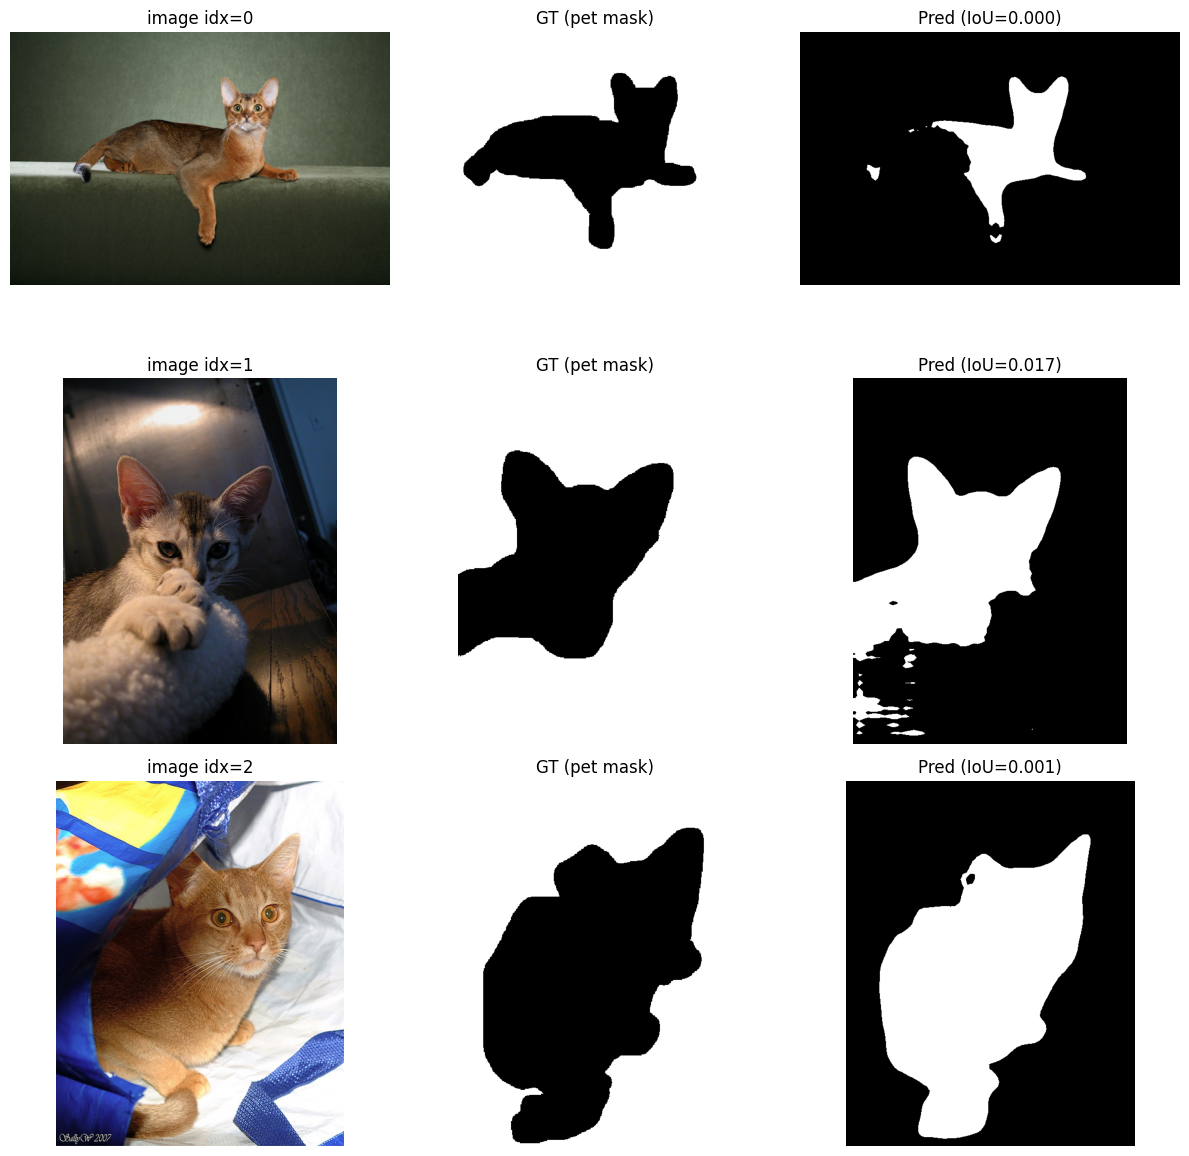

In [79]:
# визуализация предсказаний модели на нескольких примерах
n = min(cfg.n_show, len(dataset_B))
fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n):
    img_pil, gt_np = dataset_B[row]
    pred_mask, (h, w) = predict_pet_mask(img_pil)  # pet вместо person

    # GT resize to model space
    gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
    gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
    gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

    iou = iou_binary(pred_mask, gt_mask)

    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_title(f"image idx={row}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(gt_mask.numpy(), cmap="gray")
    axes[row, 1].set_title("GT (pet mask)")  # pet вместо person
    axes[row, 1].axis("off")

    axes[row, 2].imshow(pred_mask.numpy(), cmap="gray")
    axes[row, 2].set_title(f"Pred (IoU={iou:.3f})")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()


In [132]:
def log_experiment(
    experiment_id: str,
    task: str,
    dataset: str,
    seed: int,
    model_summary: str,
    optimizer: str,
    lr: float,
    epochs_trained: int,
    best_val_accuracy: float = None,
    test_accuracy: float = None,
    precision: float = None,
    recall: float = None,
    mean_iou: float = None,
    notes: str = ""
):
    """
    Минимальная функция логирования экспериментов в runs.csv
    """
    experiment_data = {
        'experiment_id': experiment_id,
        'task': task,
        'dataset': dataset,
        'seed': seed,
        'model_summary': model_summary,
        'optimizer': optimizer,
        'lr': lr,
        'epochs_trained': epochs_trained,
        'best_val_accuracy': best_val_accuracy,
        'test_accuracy': test_accuracy,
        'precision': precision,
        'recall': recall,
        'mean_iou': mean_iou,
        'notes': notes
    }
    
    runs_file = 'artifacts/runs.csv'
    if os.path.exists(runs_file):
        df_existing = pd.read_csv(runs_file)
        df_new = pd.DataFrame([experiment_data])
        df_final = pd.concat([df_existing, df_new], ignore_index=True)
    else:
        df_final = pd.DataFrame([experiment_data])
    
    # Сохраняем
    df_final.to_csv(runs_file, index=False)
    print(f"[{experiment_id}] Сохранено в runs.csv")
    
    return df_final

## Эксперименты

### Часть A (S10): классификация, аугментации и transfer learning

In [107]:
stl10_full = torchvision.datasets.STL10('./data', split='train', download=True)
train_size = int(0.8 * len(stl10_full))
val_size = len(stl10_full) - train_size
train_idx, val_idx = torch.utils.data.random_split(range(len(stl10_full)), [train_size, val_size], 
                                                  generator=torch.Generator())

#### C1 (simple-cnn-base): простая CNN без аугментаций

In [99]:
stl10_train_C1 = torchvision.datasets.STL10(DATA_DIR, split='train', transform=basic_transform, download=True)
train_size_C1 = int(0.8 * len(stl10_train_C1))
val_size_C1 = len(stl10_train_C1) - train_size
stl10_train_C1, stl10_val_C1 = random_split(stl10_train_C1, [train_size_C1, val_size_C1], generator=torch.Generator())

train_loader_C1 = DataLoader(stl10_train_C1, BATCH_SIZE, shuffle=True)
val_loader_C1 = DataLoader(stl10_val_C1, BATCH_SIZE, shuffle=False)
test_loader_C1 = DataLoader(torchvision.datasets.STL10('./data', split='test', transform=basic_transform), BATCH_SIZE)

# Простая CNN
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 12 * 12, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

Epoch 01/20 | lr 1.00e-03 | train loss 2.0067, acc 0.259 | val loss 1.6689, acc 0.413 | 33.0s
Epoch 02/20 | lr 1.00e-03 | train loss 1.5530, acc 0.416 | val loss 1.4834, acc 0.467 | 32.7s
Epoch 03/20 | lr 1.00e-03 | train loss 1.3617, acc 0.507 | val loss 1.3600, acc 0.516 | 33.1s
Epoch 04/20 | lr 1.00e-03 | train loss 1.1856, acc 0.562 | val loss 1.2162, acc 0.576 | 32.9s
Epoch 05/20 | lr 1.00e-03 | train loss 1.0089, acc 0.630 | val loss 1.2736, acc 0.541 | 34.6s
Epoch 06/20 | lr 1.00e-03 | train loss 0.8390, acc 0.701 | val loss 1.2324, acc 0.581 | 33.8s
Epoch 07/20 | lr 1.00e-03 | train loss 0.7448, acc 0.731 | val loss 1.1922, acc 0.589 | 33.4s
Epoch 08/20 | lr 1.00e-03 | train loss 0.5520, acc 0.810 | val loss 1.2248, acc 0.621 | 33.0s
Epoch 09/20 | lr 1.00e-03 | train loss 0.4105, acc 0.853 | val loss 1.3091, acc 0.606 | 33.3s
Epoch 10/20 | lr 1.00e-03 | train loss 0.3093, acc 0.896 | val loss 1.5128, acc 0.613 | 32.8s
Epoch 11/20 | lr 1.00e-03 | train loss 0.2745, acc 0.910 | v

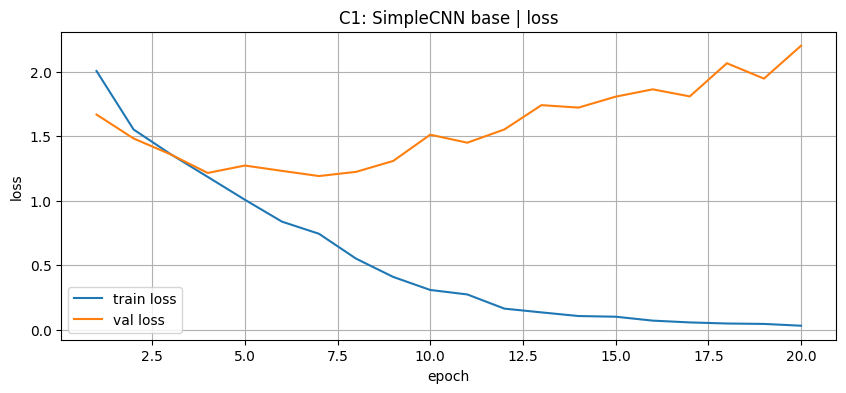

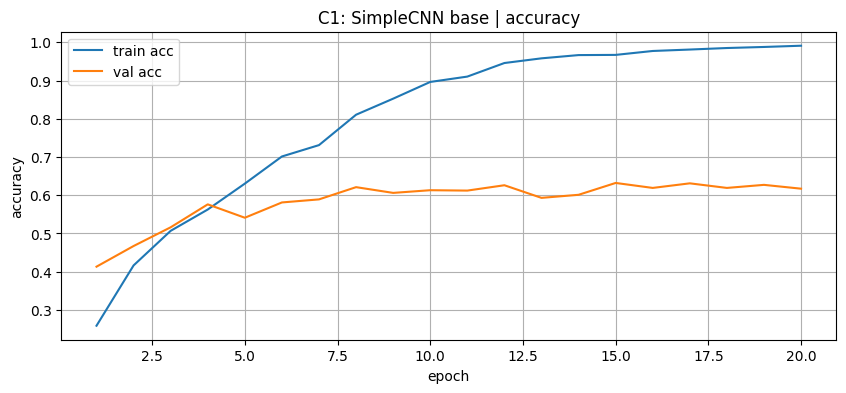

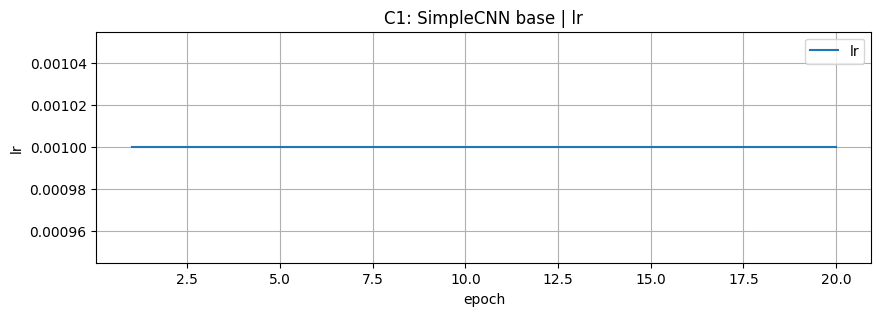

In [100]:
model_c1 = SimpleCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer_c1 = torch.optim.Adam(model_c1.parameters(), lr=0.001)

history_c1 = fit(model_c1, train_loader_C1, val_loader_C1, optimizer_c1, criterion, epochs=20)
best_val_acc_c1 = max(history_c1["val_acc"])
test_loss, test_acc_c1 = evaluate(model_c1, test_loader, criterion)

plot_history(history_c1, "C1: SimpleCNN base")

In [133]:
log_experiment(
    experiment_id='C1',
    task='classification',
    dataset='STL10',
    seed=RANDOM_STATE,
    model_summary='SimpleCNN 3conv+2fc',
    optimizer='Adam',
    lr=0.001,
    epochs_trained=len(history_c1["val_acc"]),
    best_val_accuracy=best_val_acc_c1,
    test_accuracy=test_acc_c1,
    notes='простая CNN без аугментаций'
)

[C1] Сохранено в runs.csv


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.001,20,0.632,0.601125,None,None,None,простая CNN без аугментаций


#### C2 (simple-cnn-aug): та же CNN, но с разумными аугментациями.

In [108]:
dataset_c2_train = torchvision.datasets.STL10(DATA_DIR, split='train', transform=train_transform)
dataset_c2_val = torchvision.datasets.STL10(DATA_DIR, split='train', transform=train_transform)
train_loader_c2 = DataLoader(torch.utils.data.Subset(dataset_c2_train, train_idx), 64, shuffle=True)
val_loader_c2 = DataLoader(torch.utils.data.Subset(dataset_c2_val, val_idx), 64, shuffle=False)

Epoch 01/20 | lr 1.00e-03 | train loss 1.9656, acc 0.265 | val loss 1.6931, acc 0.365 | 38.1s
Epoch 02/20 | lr 1.00e-03 | train loss 1.6665, acc 0.375 | val loss 1.5914, acc 0.402 | 38.8s
Epoch 03/20 | lr 1.00e-03 | train loss 1.5197, acc 0.432 | val loss 1.4320, acc 0.469 | 39.6s
Epoch 04/20 | lr 1.00e-03 | train loss 1.4198, acc 0.470 | val loss 1.3580, acc 0.512 | 38.2s
Epoch 05/20 | lr 1.00e-03 | train loss 1.3344, acc 0.507 | val loss 1.2996, acc 0.524 | 38.2s
Epoch 06/20 | lr 1.00e-03 | train loss 1.2901, acc 0.517 | val loss 1.2759, acc 0.532 | 37.9s
Epoch 07/20 | lr 1.00e-03 | train loss 1.2697, acc 0.531 | val loss 1.2173, acc 0.576 | 38.0s
Epoch 08/20 | lr 1.00e-03 | train loss 1.1740, acc 0.559 | val loss 1.1980, acc 0.557 | 38.0s
Epoch 09/20 | lr 1.00e-03 | train loss 1.1794, acc 0.567 | val loss 1.1739, acc 0.566 | 37.9s
Epoch 10/20 | lr 1.00e-03 | train loss 1.1004, acc 0.596 | val loss 1.1390, acc 0.610 | 38.4s
Epoch 11/20 | lr 1.00e-03 | train loss 1.0873, acc 0.607 | v

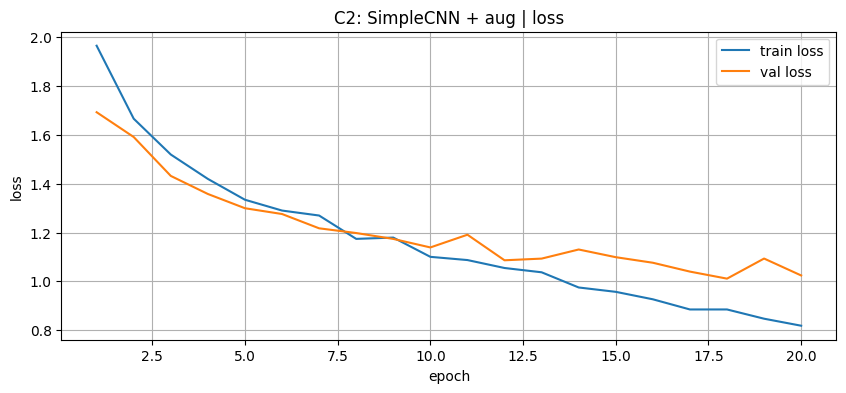

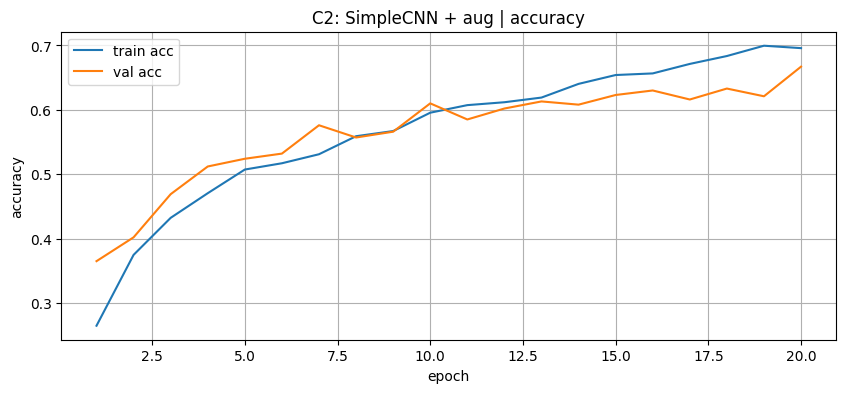

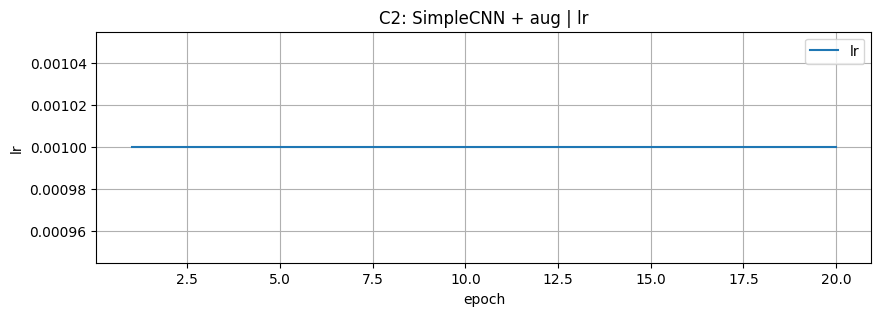

In [109]:
model_c2 = SimpleCNN().to(DEVICE)
optimizer_c2 = torch.optim.Adam(model_c2.parameters(), lr=0.001)

history_c2 = fit(model_c2, train_loader_c2, val_loader_c2, optimizer_c2, criterion, epochs=20)
best_val_acc_c2 = max(history_c2["val_acc"])
test_loss, test_acc_c2 = evaluate(model_c2, test_loader, criterion)

plot_history(history_c2, "C2: SimpleCNN + aug")

In [134]:
log_experiment(
    experiment_id='C2',
    task='classification',
    dataset='STL10',
    seed=RANDOM_STATE,
    model_summary='SimpleCNN 3conv+2fc',
    optimizer='Adam',
    lr=0.001,
    epochs_trained=len(history_c2["val_acc"]),
    best_val_accuracy=best_val_acc_c2,
    test_accuracy=test_acc_c2,
    notes='та же CNN, но с разумными аугментациями'
)

[C2] Сохранено в runs.csv


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.001,20,0.632,0.601125,NaN,NaN,NaN,простая CNN без аугментаций
1,C2,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.001,20,0.667,0.666875,None,None,None,"та же CNN, но с разумными аугментациями"


#### C3 (resnet18-head-only)

In [117]:
def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=10, weights=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))

weights: ResNet18_Weights.IMAGENET1K_V1
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Polina/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [118]:
dataset_c3_train = torchvision.datasets.STL10(DATA_DIR, split='train', transform=resnet_transform)
dataset_c3_val = torchvision.datasets.STL10(DATA_DIR, split='train', transform=resnet_transform)
train_loader_c3 = DataLoader(torch.utils.data.Subset(dataset_c3_train, train_idx), 64, shuffle=True)
val_loader_c3 = DataLoader(torch.utils.data.Subset(dataset_c3_val, val_idx), 64, shuffle=False)
test_loader_c3 = DataLoader(torchvision.datasets.STL10(DATA_DIR, split='test', transform=resnet_transform), 64)

Epoch 01/3 | lr 1.00e-03 | train loss 1.0977, acc 0.712 | val loss 0.4564, acc 0.910 | 156.8s
Epoch 02/3 | lr 1.00e-03 | train loss 0.3731, acc 0.919 | val loss 0.2828, acc 0.937 | 156.6s
Epoch 03/3 | lr 1.00e-03 | train loss 0.2692, acc 0.932 | val loss 0.2310, acc 0.943 | 156.7s


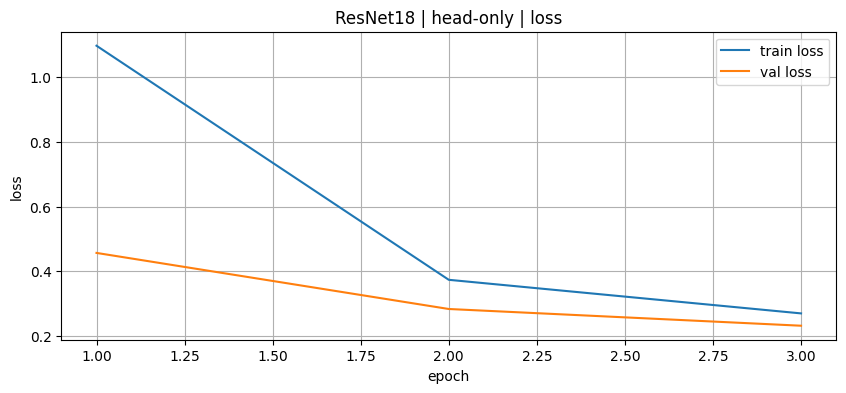

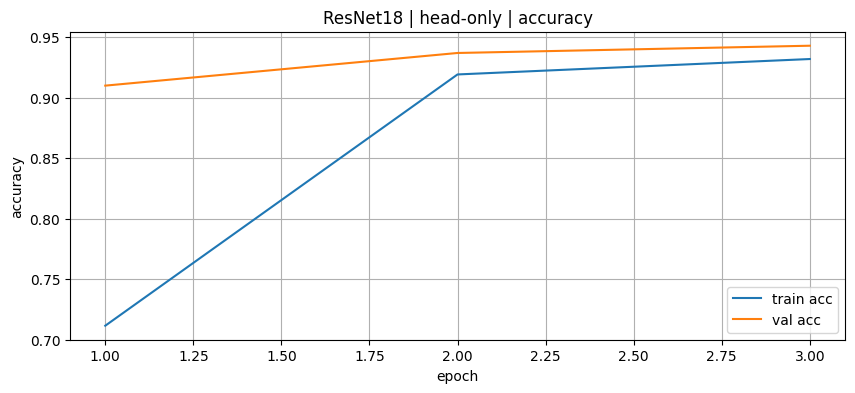

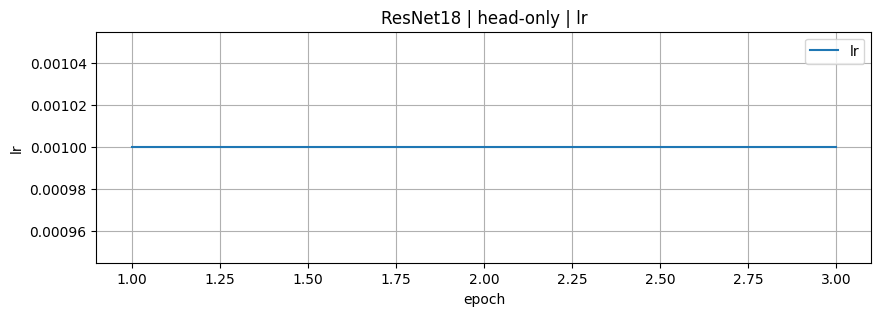

In [122]:
EPOCHS_HEAD = 3 if FAST_MODE else 8
EPOCHS_FT   = 3 if FAST_MODE else 8

criterion_c3 = nn.CrossEntropyLoss()

model_c3 = build_resnet18(num_classes=10, weights=weights).to(DEVICE)

# freeze всё
set_requires_grad(model_c3, False)
# размораживаем только голову
set_requires_grad(model_c3.fc, True)

optimizer_c3 = torch.optim.Adam(model_c3.fc.parameters(), lr=0.001)

hist_c3 = fit(model_c3, train_loader_c3, val_loader_c3, optimizer_c3, criterion_c3, epochs=EPOCHS_HEAD, verbose=True)
plot_history(hist_c3, title="ResNet18 | head-only")

In [135]:
best_val_acc_c3 = max(hist_c3["val_acc"])
test_loss, test_acc_c3 = evaluate(model_c3, test_loader_c3, criterion_c1)

log_experiment(
    experiment_id='C3',
    task='classification',
    dataset='STL10',
    seed=RANDOM_STATE,
    model_summary='ResNet18 pretrained, head-only',
    optimizer='Adam',
    lr=0.001,
    epochs_trained=len(hist_c3["val_acc"]),
    best_val_accuracy=best_val_acc_c3,
    test_accuracy=test_acc_c3,
    notes='ResNet18 с pretrained weights; backbone заморожен, обучается только классификационная голова.'
)

[C3] Сохранено в runs.csv


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.001,20,0.632,0.601125,NaN,NaN,NaN,простая CNN без аугментаций
1,C2,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.001,20,0.667,0.666875,NaN,NaN,NaN,"та же CNN, но с разумными аугментациями"
2,C3,classification,STL10,19,"ResNet18 pretrained, head-only",Adam,0.001,3,0.943,0.943125,None,None,None,ResNet18 с pretrained weights; backbone заморо...


#### C4 (resnet18-finetune)

Epoch 01/3 | lr 1.00e-03 | train loss 0.2222, acc 0.946 | val loss 0.2046, acc 0.945 | 202.1s
Epoch 02/3 | lr 1.00e-03 | train loss 0.1897, acc 0.951 | val loss 0.1927, acc 0.944 | 201.6s
Epoch 03/3 | lr 1.00e-03 | train loss 0.1767, acc 0.953 | val loss 0.1823, acc 0.944 | 201.5s


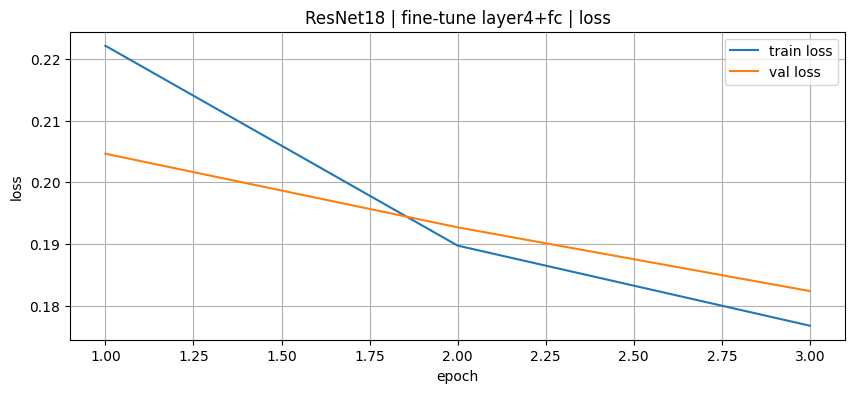

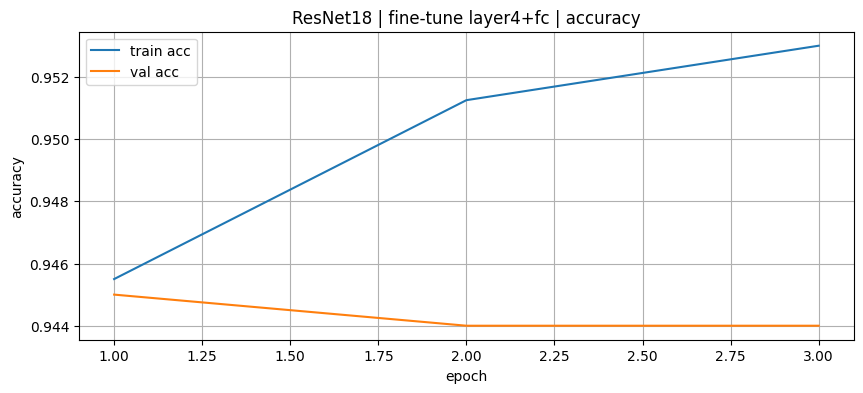

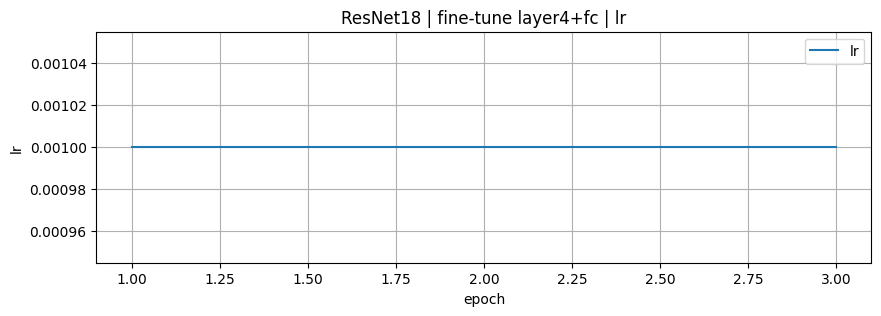

In [127]:
set_requires_grad(model_c3.layer4, True)
set_requires_grad(model_c3.fc, True)

# param groups: backbone меньше, head больше
params = [
    {"params": model_c3.layer4.parameters(), "lr": 1e-4},
    {"params": model_c3.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

hist_ft = fit(model_c3, train_loader_c3, val_loader_c3, optimizer_c3, criterion_c3, epochs=EPOCHS_FT, verbose=True)
plot_history(hist_ft, title="ResNet18 | fine-tune layer4+fc")

In [136]:
best_val_acc_c4 = max(hist_ft["val_acc"])
test_loss_c4, test_acc_c4 = evaluate(model_c3, test_loader_c3, criterion)

# Логируем C4
log_experiment(
    experiment_id='C4',
    task='classification',
    dataset='STL10',
    seed=RANDOM_STATE,
    model_summary='ResNet18 pretrained, layer4+fc',
    optimizer='Adam',
    lr=0.0001,
    epochs_trained=len(hist_ft["val_acc"]),
    best_val_accuracy=best_val_acc_c4,
    test_accuracy=test_acc_c4,
    notes='ResNet18 с pretrained weights; частичное fine-tune (например, layer4 + fc, либо другой близкий по смыслу вариант).'
)

[C4] Сохранено в runs.csv


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.0010,20,0.632,0.601125,NaN,NaN,NaN,простая CNN без аугментаций
1,C2,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.0010,20,0.667,0.666875,NaN,NaN,NaN,"та же CNN, но с разумными аугментациями"
2,C3,classification,STL10,19,"ResNet18 pretrained, head-only",Adam,0.0010,3,0.943,0.943125,NaN,NaN,NaN,ResNet18 с pretrained weights; backbone заморо...
3,C4,classification,STL10,19,"ResNet18 pretrained, layer4+fc",Adam,0.0001,3,0.945,0.943125,None,None,None,ResNet18 с pretrained weights; частичное fine-...


In [234]:
best_epoch_ft = np.argmax(hist_ft["val_acc"])
torch.save({
    'model_state_dict': model_c3.state_dict(),
    'best_val_acc': best_val_acc_c4,
    'best_epoch': best_epoch_ft,
    'test_acc': test_acc_c4,
}, 'artifacts/best_classifier.pt')
print("Сохранено best_classifier.pt")

Сохранено best_classifier.pt


In [235]:
best_config = {
    # Основные параметры
    "dataset": "STL10",
    "task": "classification", 
    "num_classes": 10,
    "architecture": "ResNet18",
    "pretrained": "IMAGENET" if weights else "None",
    
    # Обучение head-only
    "head_only_epochs": EPOCHS_HEAD,
    "head_optimizer": "Adam",
    "head_lr": 0.001,
    
    # Fine-tune
    "finetune_layers": "layer4+fc",
    "finetune_epochs": EPOCHS_FT,
    "finetune_optimizer": "Adam",
    "finetune_lr_layer4": 1e-4,
    "finetune_lr_fc": 1e-3,
    "weight_decay": 1e-4,
    
    # Метрики лучшей модели
    "best_val_accuracy": float(best_val_acc_c4),
    "test_accuracy": float(test_acc_c4),
    "best_epoch": int(best_epoch_ft),
    
    # Воспроизводимость
    "seed": int(RANDOM_STATE),
    "device": str(DEVICE),
    
    "batch_size": 64,
    "transforms": "resnet_transform",  # предполагается стандартный STL10 transform
}

# Сохранение плоского JSON конфига
with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)


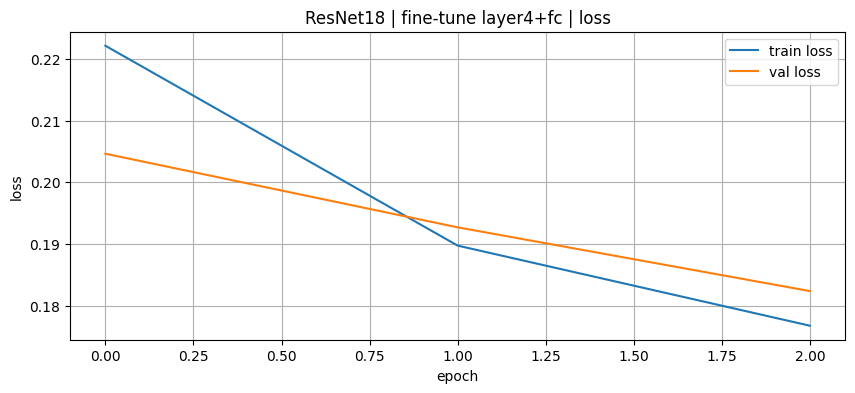

In [241]:
plt.figure(figsize=(10, 4))
plt.plot(hist_ft["train_loss"], label="train loss")
plt.plot(hist_ft["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("ResNet18 | fine-tune layer4+fc | loss")
plt.grid(True)
plt.legend()
plt.savefig('artifacts/figures/classification_curves_best.png')

### 

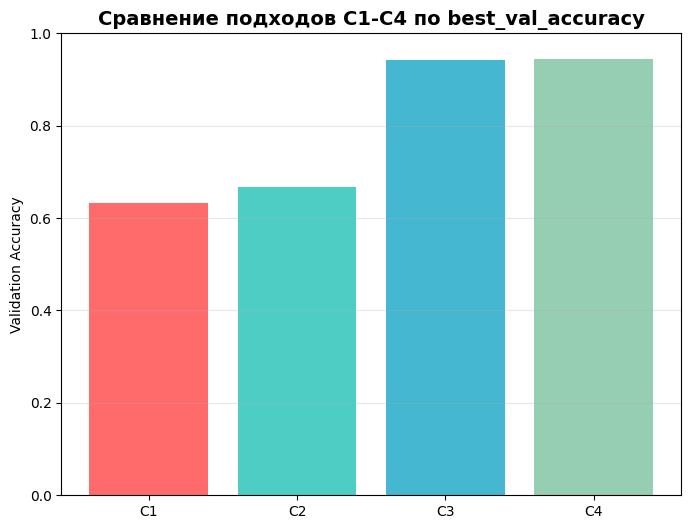

In [245]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
models = ['C1', 'C2', 'C3', 'C4']
accuracies = [best_val_acc_c1, best_val_acc_c2, best_val_acc_c3, best_val_acc_c4]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

bars = ax.bar(models, accuracies, color=colors)
ax.set_title('Сравнение подходов C1-C4 по best_val_accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Validation Accuracy')
ax.set_ylim(0, 1)

plt.grid(True, alpha=0.3, axis='y')
plt.savefig('artifacts/figures/classification_compare.png')

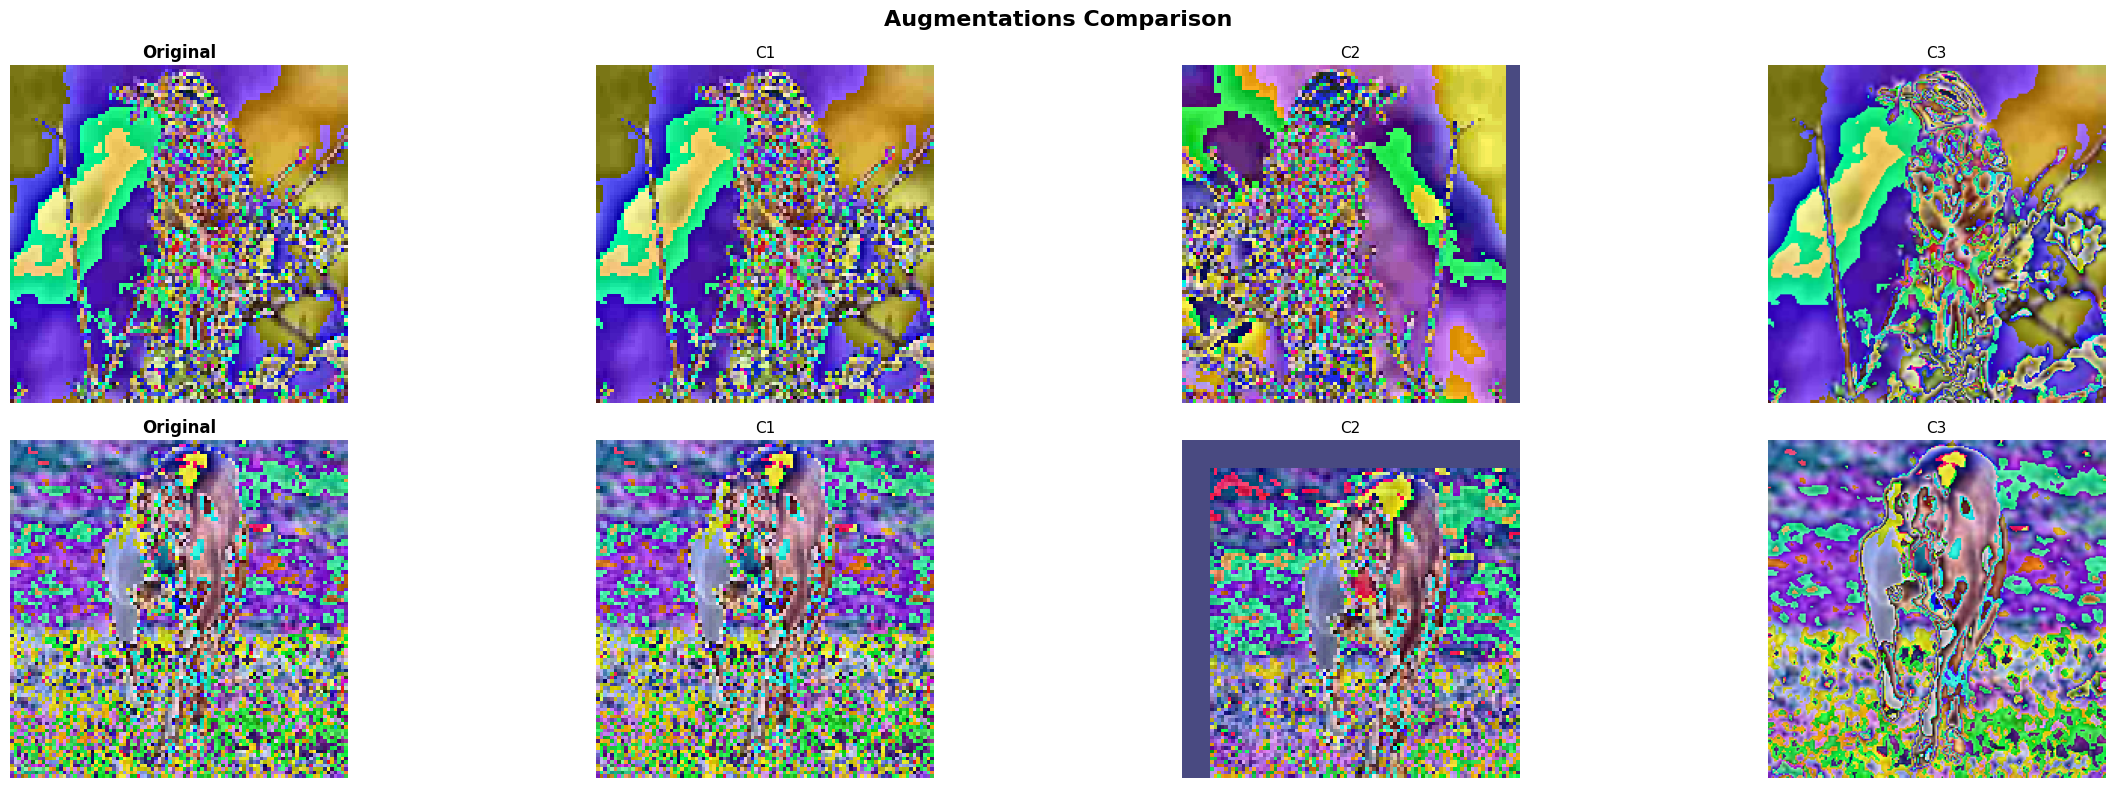

In [252]:
fig, axes = plt.subplots(2, 4, figsize=(25, 4*2))
    
datasets = {
    'C1 (basic)': stl10_train_C1.dataset if hasattr(stl10_train_C1, 'dataset') else stl10_train_C1,
    'C2 (train)': dataset_c2_train,
    'C3 (subset)': dataset_c3_train, 
    }
    
transforms = {
    'C1 (basic)': basic_transform,
    'C2 (train)': train_transform,
    'C3 (subset)': resnet_transform,
}
    
for row in range(2):
    img_idx = row  # берем последовательные изображения
        
    # Колонка 0: Original (без трансформаций)
    orig_img, _ = datasets['C1 (basic)'][img_idx] if hasattr(datasets['C1 (basic)'], '__getitem__') else datasets['C1 (basic)'][img_idx]
    if isinstance(orig_img, torch.Tensor):
        orig_img = F.to_pil_image(orig_img)
    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_title('Original', fontsize=12, fontweight='bold')
    axes[row, 0].axis('off')
        
    # Колонки 1-4: трансформации C1-C4
    for col, (name, dataset) in enumerate(datasets.items(), 1):
        try:
            img_pil, _ = dataset[img_idx]
            if isinstance(img_pil, torch.Tensor):
                img_pil = F.to_pil_image(img_pil)
            axes[row, col].imshow(img_pil)
            axes[row, col].set_title(name.split()[0], fontsize=11)
            axes[row, col].axis('off')
        except:
            axes[row, col].text(0.5, 0.5, 'N/A', ha='center', va='center', transform=axes[row, col].transAxes)
            axes[row, col].set_title(name.split()[0], fontsize=11)
            axes[row, col].axis('off')
    
plt.suptitle('Augmentations Comparison', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('artifacts/figures/augmentations_preview.png')

#### V1: базовая постобработка маски

In [216]:
@torch.no_grad()
def predict_pet_mask_v1(img_pil: Image.Image, threshold: float = 0.5) -> tuple[torch.Tensor, tuple[int, int]]:
    x = preprocess(img_pil).unsqueeze(0).to(DEVICE)  # [1,3,H,W]
    out = model(x)["out"][0]  # [C,H,W]
    pred = out.argmax(0)      # [H,W]
    pet_mask = (pred == int(PET_IDX)).to(torch.uint8)
    return pet_mask.cpu(), x.shape[-2:]

In [218]:
def iou_binary(pred: torch.Tensor, gt: torch.Tensor) -> float:
    pred = pred.bool()
    gt = gt.bool()
    inter = (pred & gt).sum().item()
    union = (pred | gt).sum().item()
    return float(inter / (union + 1e-9))

def eval_subset(indices: List[int], version: str = "V1", threshold: float = 0.5) -> Dict[str, float]:
    predict_fn = predict_pet_mask_v1 if version == "V1" else predict_pet_mask_v2
    ious = []
    
    for idx in indices:
        img_pil, gt_np = dataset[idx]
        pred_mask, (h, w) = predict_fn(img_pil, threshold=threshold)

        # resize GT to model space
        gt_pil = Image.fromarray((gt_np *  255).astype(np.uint8))
        gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

        ious.append(iou_binary(pred_mask, gt_mask))

    return {
        "version": version,
        "threshold": threshold,
        "n": float(len(ious)),
        "mean_IoU": float(np.mean(ious)),
        "median_IoU": float(np.median(ious)),
        "min_IoU": float(np.min(ious)),
        "max_IoU": float(np.max(ious)),
    }

# 2 режима оценки
if cfg.fast_mode:
    eval_indices = list(range(min(20, len(dataset))))
else:
    eval_indices = list(range(len(dataset)))

# V1: Базовая (argmax)
metrics_v1 = eval_subset(eval_indices, version="V1", threshold=0.5)

In [220]:
metrics_v1

{'version': 'V1',
 'threshold': 0.5,
 'n': 20.0,
 'mean_IoU': 0.0011732393348639909,
 'median_IoU': 2.6636131228272237e-05,
 'min_IoU': 0.0,
 'max_IoU': 0.01729422641146255}

In [230]:
log_experiment(
    experiment_id="V1",
    task="segmentation",
    dataset="OxfordIIITPet",
    seed=RANDOM_STATE,
    model_summary=f"DeepLabV3_ResNet50 pretrained COCO, PET_IDX={PET_IDX}, threshold=0.5",
    optimizer=None,
    lr=0.0,
    epochs_trained=0,
    mean_iou=metrics_v1['mean_IoU'],
    notes=f"базовая постобработка маски]"
)

[V1] Сохранено в runs.csv


C:\Users\Polina\AppData\Local\Temp\ipykernel_165040\4261354937.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat([df_existing, df_new], ignore_index=True)


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.0010,20,0.632,0.601125,NaN,NaN,NaN,простая CNN без аугментаций
1,C2,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.0010,20,0.667,0.666875,NaN,NaN,NaN,"та же CNN, но с разумными аугментациями"
2,C3,classification,STL10,19,"ResNet18 pretrained, head-only",Adam,0.0010,3,0.943,0.943125,NaN,NaN,NaN,ResNet18 с pretrained weights; backbone заморо...
3,C4,classification,STL10,19,"ResNet18 pretrained, layer4+fc",Adam,0.0001,3,0.945,0.943125,NaN,NaN,NaN,ResNet18 с pretrained weights; частичное fine-...
4,V1,segmentation,OxfordIIITPet,19,"DeepLabV3_ResNet50 pretrained COCO, PET_IDX=8,...",None,0.0000,0,NaN,NaN,NaN,NaN,0.001173,базовая постобработка маски]


#### V2: альтернативная постобработка маски

In [226]:
@torch.no_grad()
def predict_pet_mask_v2(img_pil: Image.Image, threshold: float = 0.1) -> tuple[torch.Tensor, tuple[int, int]]:
    x = preprocess(img_pil).unsqueeze(0).to(DEVICE)
    out = model(x)["out"][0]
    
    pred_class = out.argmax(0)
    pet_mask = (pred_class == int(PET_IDX)).float()
    pet_probs = torch.softmax(out, dim=0)[PET_IDX]
    
    pet_mask = (pet_probs > threshold).to(torch.uint8)
    
    return pet_mask.cpu(), x.shape[-2:]

In [227]:
metrics_v2 = eval_subset(eval_indices, version="V2", threshold=0.2)
metrics_v2

{'version': 'V2',
 'threshold': 0.2,
 'n': 20.0,
 'mean_IoU': 0.010443135219040407,
 'median_IoU': 0.0019508795019203967,
 'min_IoU': 0.0,
 'max_IoU': 0.1168034371643391}

In [231]:
log_experiment(
    experiment_id="V2",
    task="segmentation",
    dataset="OxfordIIITPet",
    seed=RANDOM_STATE,
    model_summary=f"DeepLabV3_ResNet50 pretrained COCO, PET_IDX={PET_IDX}, threshold=0.1",
    optimizer=None,
    lr=0.0,
    epochs_trained=0,
    mean_iou=metrics_v2['mean_IoU'],
    notes=f"альтернативная постобработка маски, другой порог для бинаризации выбранного foreground-класса"
)

[V2] Сохранено в runs.csv


C:\Users\Polina\AppData\Local\Temp\ipykernel_165040\4261354937.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat([df_existing, df_new], ignore_index=True)


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.0010,20,0.632,0.601125,NaN,NaN,NaN,простая CNN без аугментаций
1,C2,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.0010,20,0.667,0.666875,NaN,NaN,NaN,"та же CNN, но с разумными аугментациями"
2,C3,classification,STL10,19,"ResNet18 pretrained, head-only",Adam,0.0010,3,0.943,0.943125,NaN,NaN,NaN,ResNet18 с pretrained weights; backbone заморо...
3,C4,classification,STL10,19,"ResNet18 pretrained, layer4+fc",Adam,0.0001,3,0.945,0.943125,NaN,NaN,NaN,ResNet18 с pretrained weights; частичное fine-...
4,V1,segmentation,OxfordIIITPet,19,"DeepLabV3_ResNet50 pretrained COCO, PET_IDX=8,...",NaN,0.0000,0,NaN,NaN,NaN,NaN,0.001173,базовая постобработка маски]
5,V2,segmentation,OxfordIIITPet,19,"DeepLabV3_ResNet50 pretrained COCO, PET_IDX=8,...",None,0.0000,0,NaN,NaN,NaN,NaN,0.010443,"альтернативная постобработка маски, другой пор..."


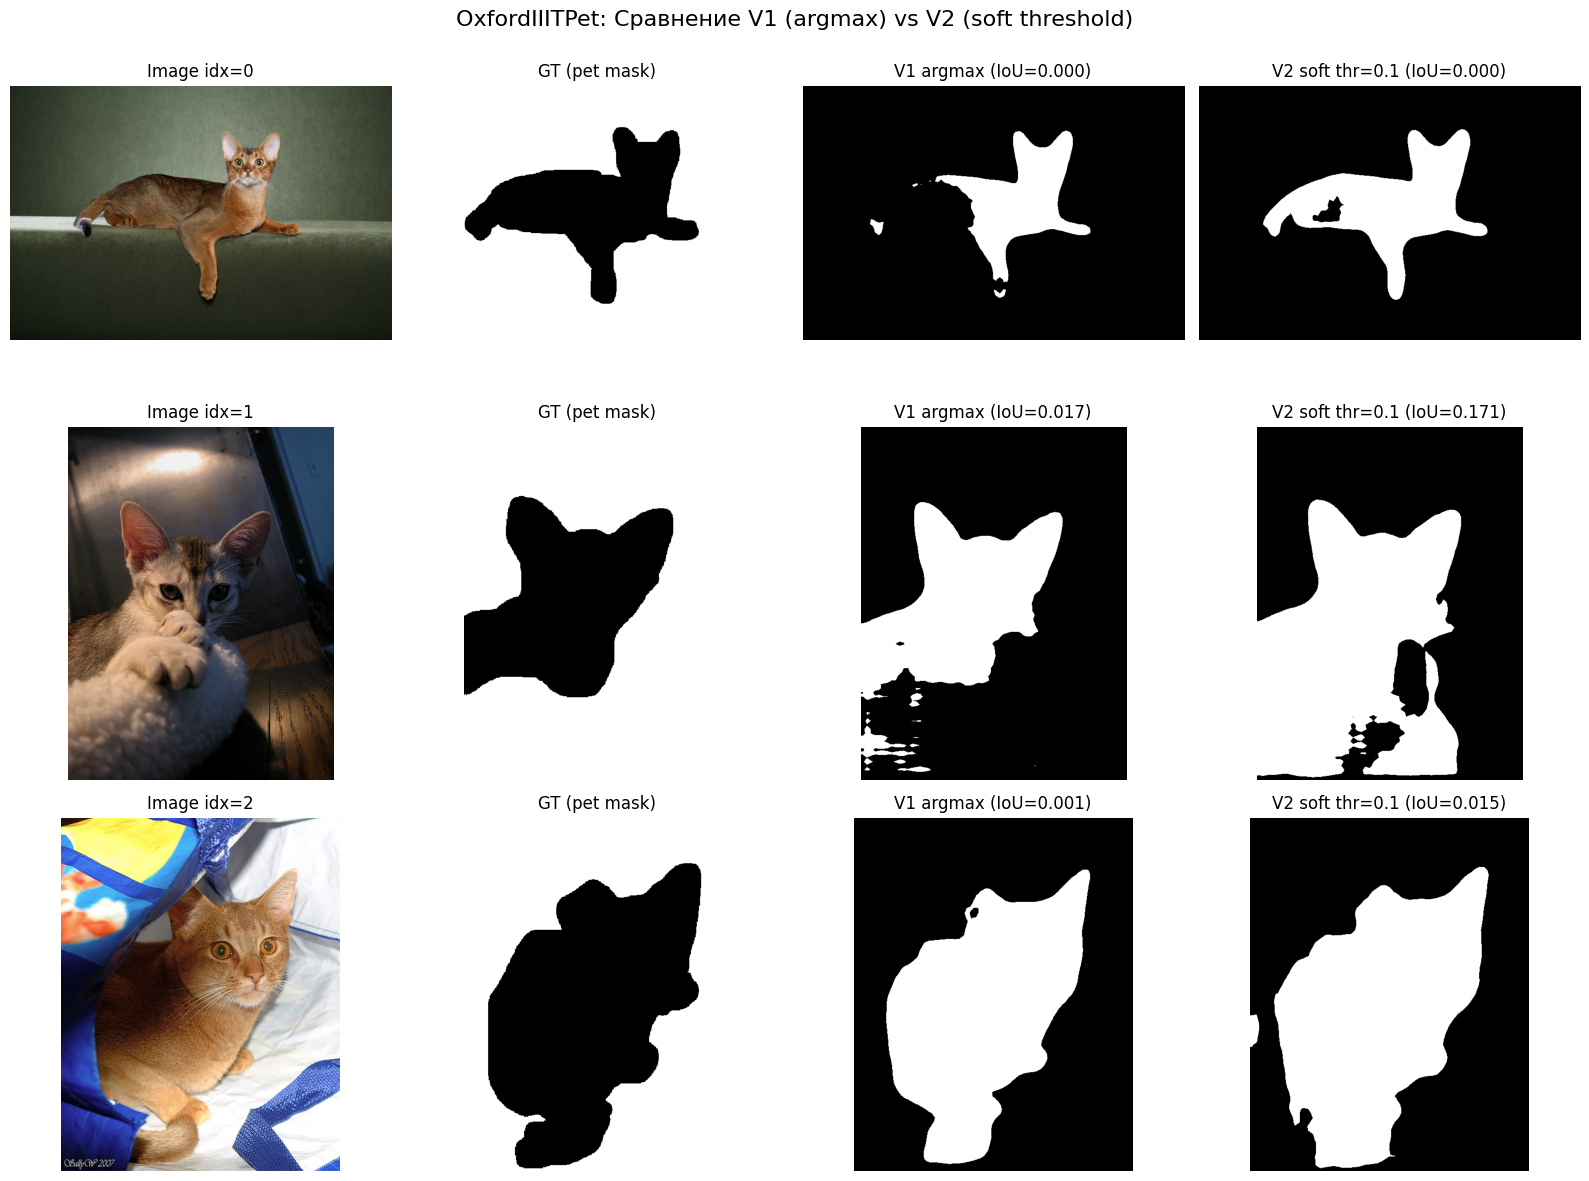

In [262]:
n = min(cfg.n_show, len(dataset))
fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n):
    img_pil, gt_np = dataset_B[row]
    
    # V1: базовая постобработка
    pred_mask_v1, (h, w) = predict_pet_mask_v1(img_pil, threshold=0.5)
    # V2: альтернативная постобработка  
    pred_mask_v2, _ = predict_pet_mask_v2(img_pil, threshold=0.1)

    # GT resize to model space (один раз)
    gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
    gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
    gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

    iou_v1 = iou_binary(pred_mask_v1, gt_mask)
    iou_v2 = iou_binary(pred_mask_v2, gt_mask)

    # Колонка 1: Исходное изображение
    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_title(f"Image idx={row}")
    axes[row, 0].axis("off")

    # Колонка 2: GT маска
    axes[row, 1].imshow(gt_mask.numpy(), cmap="gray")
    axes[row, 1].set_title("GT (pet mask)")
    axes[row, 1].axis("off")

    # Колонка 3: V1 предсказание (argmax)
    axes[row, 2].imshow(pred_mask_v1.numpy(), cmap="gray")
    axes[row, 2].set_title(f"V1 argmax (IoU={iou_v1:.3f})")
    axes[row, 2].axis("off")

    # Колонка 4: V2 предсказание (soft threshold)
    axes[row, 3].imshow(pred_mask_v2.numpy(), cmap="gray")
    axes[row, 3].set_title(f"V2 soft thr=0.1 (IoU={iou_v2:.3f})")
    axes[row, 3].axis("off")

plt.suptitle("OxfordIIITPet: Сравнение V1 (argmax) vs V2 (soft threshold)", fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_examples.png')

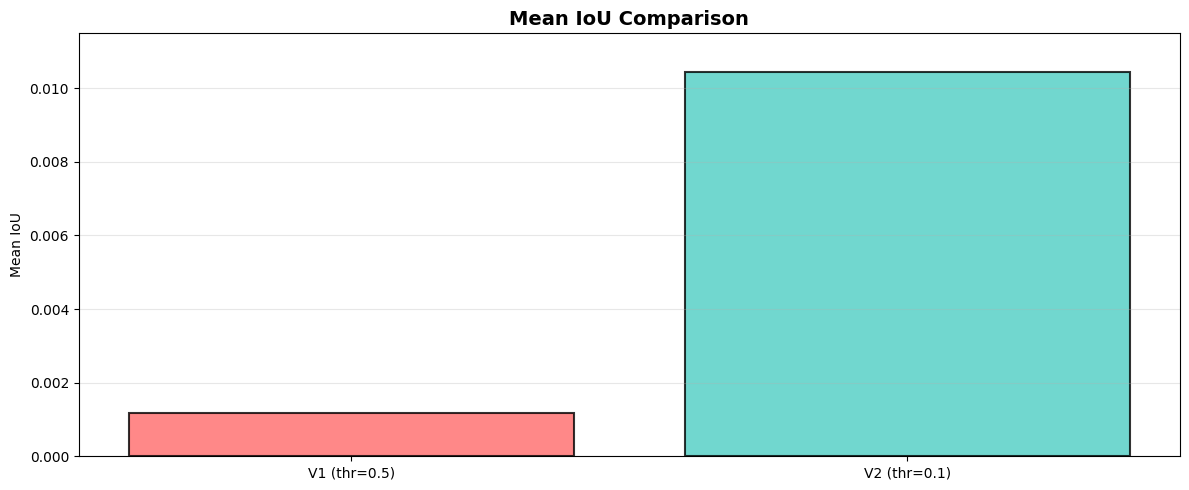

In [260]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

# 1) Bar plot: mean IoU V1 vs V2
categories = ['V1 (thr=0.5)', 'V2 (thr=0.1)']
mean_ious = [metrics_v1['mean_IoU'], metrics_v2['mean_IoU']]

bars = ax.bar(categories, mean_ious, color=['#FF6B6B', '#4ECDC4'], 
               alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_title('Mean IoU Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean IoU')
ax.set_ylim(0, max(mean_ious)*1.1)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_metrics.png')